<div style='text-align: center;'>
<img src="images/math60082-banner.png" alt="image" width="80%" height="auto">
</div>

# Lab Workbook - Week 4

Now we have a random number generator we can sample from the available probability distributions. The most commonly used in finance would be:
- `normal` the normal distribution $x\sim N(\mu,\sigma^2)$ with mean $\mu$ and variance $\sigma^2$
- `uniform` the uniform distribution $x\sim U(a,b)$ over the interval $[a,b]$ can be used to calculate if an event happens according to some known probability
- `exponential` the exponential distribution $x\sim$ Exp $(\lambda)$ with rate parameter $\lambda$ to generate the waiting time of a Poisson distribution with mean $\lambda$

# Tasks

1. Generate 1000 numbers from each of the distributions, and plot out a histogram of the frequency distribution

2. Regenerate the graphs with $n=10,000$ $n=100,000$ $n=1,000,000$ numbers from the distribution, what do you notice happens?


Assume $x \sim N(0,1)$ is a random draw from the normal distribution, the random variable $F=f(x)$, and the function $f(x)$ is given by
$$
f(x) = \begin{cases}
x^2 & \text{ if } x \leq 1 \\
0 & \text{ if } x > 1
\end{cases}.
$$

3. Use Monte Carlo simulations, can you calculate the expectation $V=\text{E}[F]$?

In [1]:
import numpy as np

In [2]:
rng = np.random.default_rng(seed=42)

In [8]:
N = 1000
sum = 0.0
for i in range(N):
    phi = rng.normal()
    if phi < 1:
        sum += phi*phi
print(sum/N)

0.5580047948357584


In [22]:
def monteCarlo(N):
    sum = 0.0
    for i in range(N):
        phi = rng.normal()
        if phi < 1:
            sum += phi*phi
    return sum/N

4. Change the value of `numberOfResults` to 20, 40, 80 and more. What properties can you identify in the graphs? Be careful, as $N$ gets large so do the computation times!


In [23]:
import matplotlib.pyplot as plt

In [24]:
K=1000
N_values = np.zeros(K)
V_values = np.zeros(K)
for k in range(K):
    N = 1000 + 100*k
    val = monteCarlo(N)
    N_values[k] = N
    V_values[k] = val

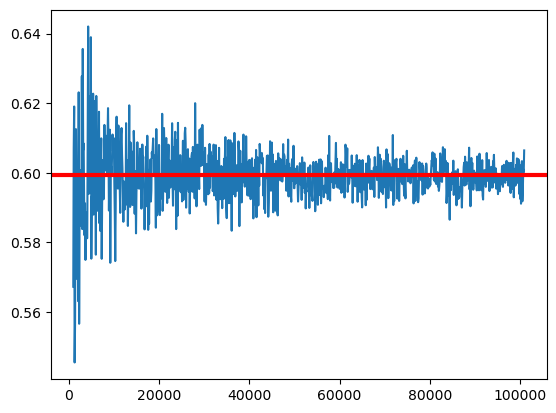

In [36]:
plt.plot(N_values,V_values)
plt.axhline( y = 0.5993740215493997 , color='r' , linewidth=3)

5.Calculate the value using numerical quadrature:-
$$
V = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^1 x^2 e^{-x^2/2} dx
$$
and use it to check the accuracy of your code. Do the results match?


In [30]:
from scipy.integrate import quad
from math import exp,sqrt,pi

In [40]:
integrand = lambda x : x*x*exp(-x*x/2.)
V = quad( integrand , a=-10 , b=1 )
print(f"Exact value V:={1/sqrt(2.0*pi)*V[0]} with error {V[1]}.")

Exact value V:=0.5993740215493997 with error 7.424344882482472e-11.


6. How can you definitively say what the error is, given that for any value of $N$ you generate a random result every time? _Hint: think about the variance of your result._


Generate a bunch of solutions with N=1000 and plot a histogram of the results.

In [43]:
K=10000
N_values = np.zeros(K)
V_values = np.zeros(K)
for k in range(K):
    N = 1000 
    val = monteCarlo(N)
    V_values[k] = val

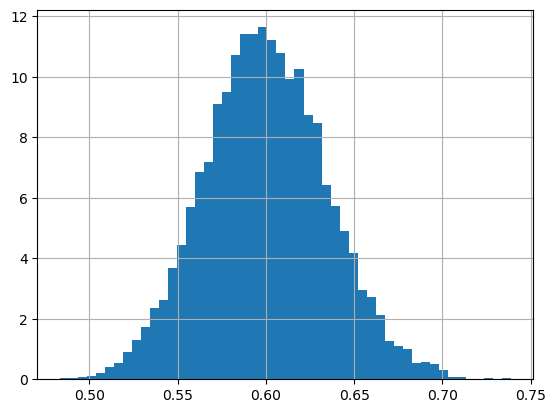

In [44]:
plt.hist(V_values, bins=50,density=True)
plt.grid(True)

We have done N=1000 times K=10000 sample paths. What is best estimate and what is the accuracy of our result?

In [45]:
print(f"Best estimate with 10,000,000 paths is {np.average(V_values)}")

Best estimate with 10,000,000 paths is 0.59986235497938


Calculate the variance of our samples $\eta$, then the variance of our sample mean is $\eta/K$ (variance divided by number of samples).

In [47]:
var_V = np.var(V_values)

In [48]:
sample_mean_var = var_V/K

In [49]:
print(f"We can be 95% confident solution is within {np.average(V_values)-1.96*sqrt(sample_mean_var)} and {np.average(V_values)+1.96*sqrt(sample_mean_var)}.")

We can be 95% confident solution is within 0.599184720028971 and 0.600539989929789.


7. How efficient is your code? Test different random number generators to see which one is best. For the more confident student, you might also investigate ways to speed up the calculations using the `numba` or `cython` libraries.

Consider asset value follows regime switching problem where
$$
dS = r dt + \sigma(X) dW
$$
and $X={L,H}$ is a continuous Markov chain with switching intensity
- $L \to H$ at continuous rate $\lambda$
- no switching back.

If the state is $X=L$, then $\sigma(L)=0.1$. If the state is $X=H$, then $\sigma(H)=0.4$.

The time to switch $h$ is exponentially distributed with $h\sim \mathrm{Exp}(\lambda)$.

Let's plot some stock paths. Assume each path is split into $K$ parts, so $\Delta t = T/K$, then
$$
\Delta S = r \Delta t + \sigma(X) \Delta W
$$
The probability we switch at time $t$ is given by
$$
\text{Prob(switch low to high)} = \lambda \Delta t
$$
$$
\text{Prob(no switch)} = 1- \lambda \Delta t
$$

In [61]:
K = 1000
r = 0.01
sigma_L = 0.1
sigma_H = 0.4
lam = 1
T = 1

In [ ]:
dt = T/K
dW = rng.normal(0,sqrt(dt),size=(K))
t_Values = np.zeros(K+1)
S_Values = np.zeros(K+1)
X_Values = np.zeros(K+1,dtype=int)
t_Values[0] = 0.0
S_Values[0] = 1.0
X_Values[0] = 0 # 0 means L and 1 means H
for k in range(K):
    if X_Values[k] == 0:
        sigma=sigma_L
    else:
        sigma=sigma_H

    t_Values[k+1] = (k+1)*dt
    S_Values[k+1] = S_Values[k] + r*dt + sigma*dW[k]
    xi = rng.uniform(0.,1.)
    if xi < lam*dt:
        X_Values[k+1] = 1
    else:
        X_Values[k+1] = X_Values[k]

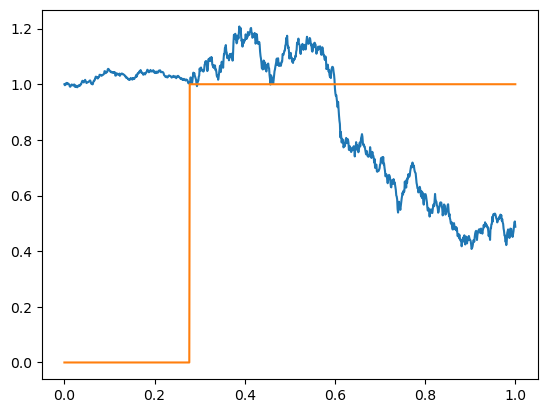

In [64]:
plt.plot(t_Values,S_Values)
plt.plot(t_Values,X_Values)